####**Introduction**

The outbreak of Coronavirus Disease 2019 (COVID-19) has had a profound impact on global health systems, economies, and societies. Since its emergence, the rapid spread of the virus has led to an unprecedented need for data-driven analysis to understand infection patterns, recovery trends, and future projections.

This project focuses on analyzing COVID-19 data collected from multiple reliable sources in the form of CSV and Excel files, containing information on confirmed cases, deaths, and recoveries across different regions, including India and the global population. By utilizing data analysis and visualization techniques, the project aims to uncover meaningful insights into the progression of the pandemic.

Python libraries such as Pandas are used to preprocess and consolidate data from various datasets, while Plotly is employed to create interactive visualizations that effectively represent trends over time. Furthermore, time series forecasting is performed using the Facebook Prophet model to predict the future number of COVID-19 cases based on existing trends.

The primary objective of this project is to analyze the rate of infection and recovery, visualize patterns in the spread of the virus, and generate short-term forecasts to better understand how the pandemic may evolve in the near future. These insights can help in informed decision-making and preparedness for potential future outbreaks.

In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [235]:
df = pd.read_csv('/content/covid_19_clean_complete.csv')

In [236]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


🏙️ Province/State: The specific state or province within a country (can be blank if not applicable).

🌍 Country/Region: The name of the country where COVID-19 cases were reported.

📍 Lat: Latitude coordinate of the region (geographical location).

📍 Long: Longitude coordinate of the region (geographical location).

📅 Date: The date on which the data was recorded.

🦠 Confirmed: The number of confirmed COVID-19 cases on that date.

⚰️ Deaths: The number of people who died due to COVID-19 on that date.

💪 Recovered: The number of people who recovered from COVID-19 on that date.


In [237]:
df.shape

(49068, 10)

In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [239]:
df.rename(columns = {
    "Province/State":"State",
    "Country/Region":"Country"},inplace=True)
df

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [240]:
df['Date'].value_counts()

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


In [241]:
df['Date'].max()

'2020-07-27'

In [242]:
top_date = df[df['Date'] == '2020-07-27']

In [243]:
top_date.head(10)

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.93911,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.15330,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.03390,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.50630,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.20270,17.873900,2020-07-27,950,41,242,667,Africa
48812,NaN,Antigua and Barbuda,17.06080,-61.796400,2020-07-27,86,3,65,18,Americas
48813,NaN,Argentina,-38.41610,-63.616700,2020-07-27,167416,3059,72575,91782,Americas
48814,NaN,Armenia,40.06910,45.038200,2020-07-27,37390,711,26665,10014,Europe
48815,Australian Capital Territory,Australia,-35.47350,149.012400,2020-07-27,113,3,109,1,Western Pacific
48816,New South Wales,Australia,-33.86880,151.209300,2020-07-27,3699,49,2989,661,Western Pacific


In [244]:
top_date.groupby(['Country'])[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,36263,1269,25198,9796
1,Albania,4880,144,2745,1991
2,Algeria,27973,1163,18837,7973
3,Andorra,907,52,803,52
4,Angola,950,41,242,667
...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,6791
183,Western Sahara,10,1,8,1
184,Yemen,1691,483,833,375
185,Zambia,4552,140,2815,1597


In [245]:
confirmed_cases = df.groupby(['Date'])['Confirmed'].sum().reset_index()
confirmed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


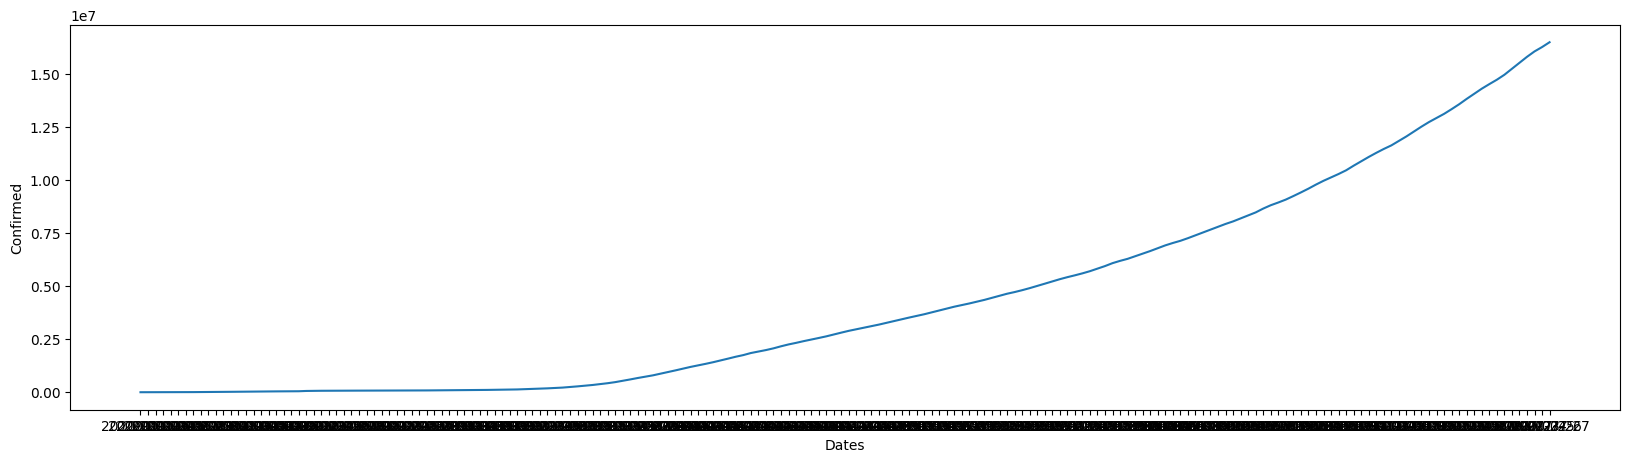

In [246]:
plt.figure(figsize = (20,5))
sns.lineplot(data = confirmed_cases, x = 'Date', y = 'Confirmed')
plt.xlabel('Dates')
plt.ylabel('Confirmed')
plt.show()

In [247]:
death_cases = df.groupby(['Date'])['Deaths'].sum().reset_index()
death_cases

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


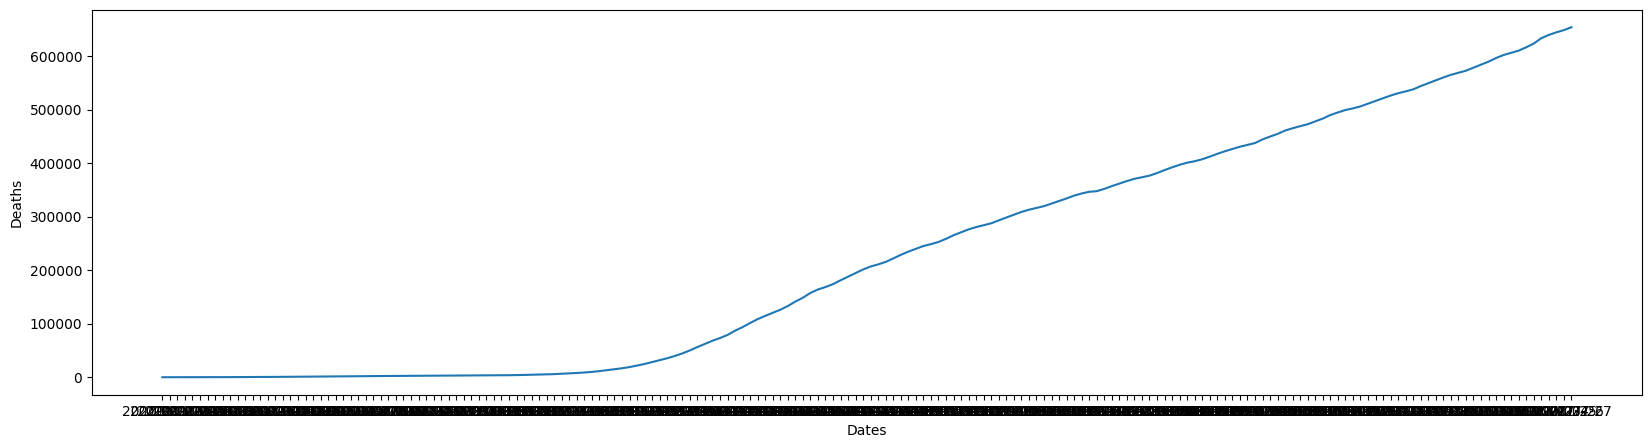

In [248]:
plt.figure(figsize = (20,5))
sns.lineplot(data = death_cases, x = 'Date', y= 'Deaths')
plt.xlabel('Dates')
plt.ylabel('Deaths')
plt.show()

In [249]:
recovered_cases = df.groupby(['Date'])['Recovered'].sum().reset_index()
recovered_cases

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


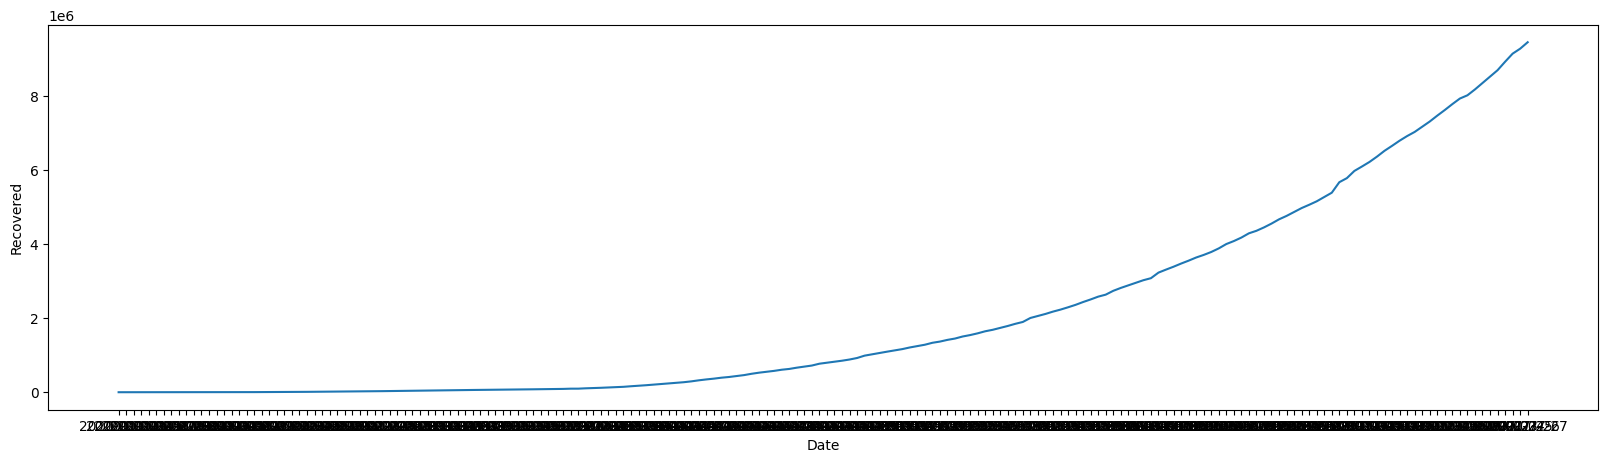

In [250]:
plt.figure(figsize = (20,5))
sns.lineplot(data = recovered_cases, x = 'Date', y = 'Recovered')
plt.xlabel('Date')
plt.ylabel('Recovered')
plt.show()

In [251]:
active_cases = df.groupby(['Date'])['Active'].sum().reset_index()
active_cases

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


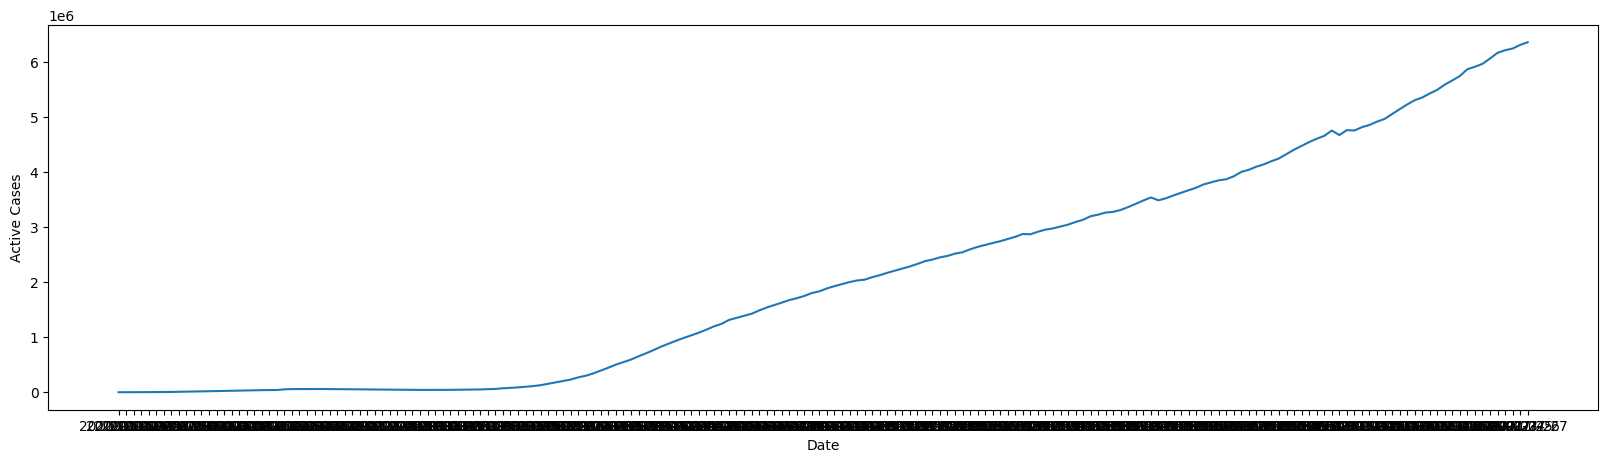

In [252]:
plt.figure(figsize = (20, 5))
sns.lineplot(data = active_cases, x= 'Date', y = 'Active')
plt.xlabel('Date')
plt.ylabel('Active Cases')
plt.show()

In [253]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   State       14664 non-null  object 
 1   Country     49068 non-null  object 
 2   Lat         49068 non-null  float64
 3   Long        49068 non-null  float64
 4   Date        49068 non-null  object 
 5   Confirmed   49068 non-null  int64  
 6   Deaths      49068 non-null  int64  
 7   Recovered   49068 non-null  int64  
 8   Active      49068 non-null  int64  
 9   WHO Region  49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [254]:
df['Date'] = pd.to_datetime(df['Date'])

In [255]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   State       14664 non-null  object        
 1   Country     49068 non-null  object        
 2   Lat         49068 non-null  float64       
 3   Long        49068 non-null  float64       
 4   Date        49068 non-null  datetime64[ns]
 5   Confirmed   49068 non-null  int64         
 6   Deaths      49068 non-null  int64         
 7   Recovered   49068 non-null  int64         
 8   Active      49068 non-null  int64         
 9   WHO Region  49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


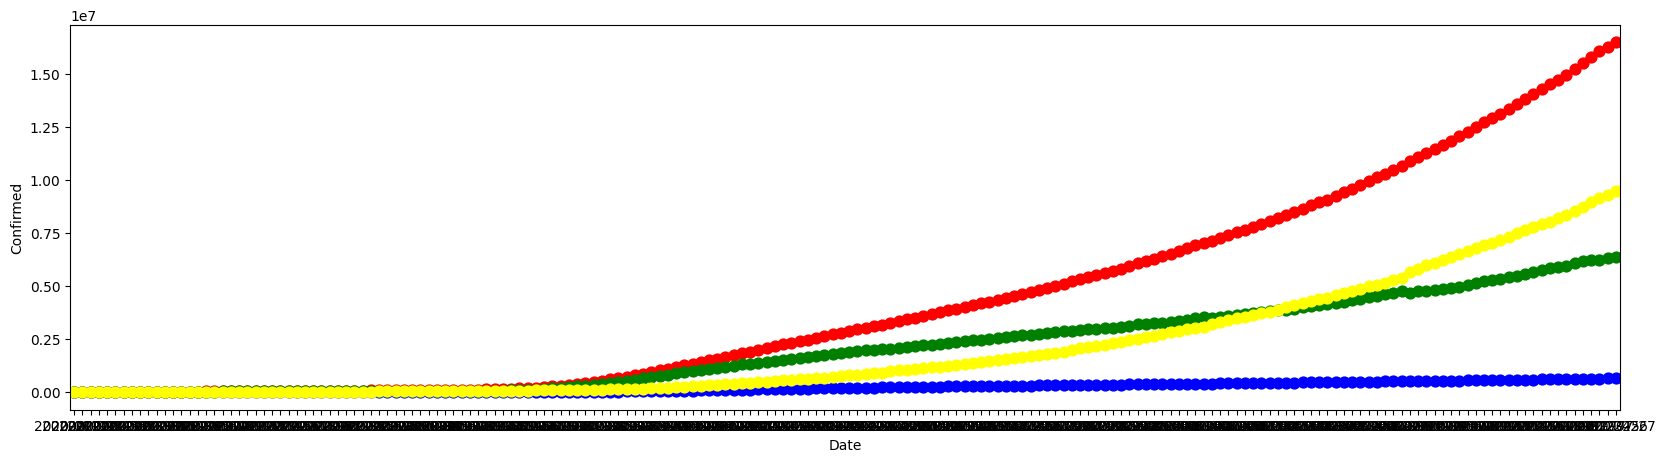

In [256]:
plt.figure(figsize = (20, 5))
sns.pointplot(data = confirmed_cases, x = 'Date', y = 'Confirmed', color = 'Red')
sns.pointplot(data = death_cases, x = 'Date', y = 'Deaths', color = 'Blue')
sns.pointplot(data = active_cases, x = 'Date', y = 'Active', color = 'Green')
sns.pointplot(data = recovered_cases, x = 'Date', y = 'Recovered', color = 'Yellow')
#plt.xlabel('Dates')
#plt.ylabel('Recovered')
plt.show()

In [257]:
#Top 3 effected countries
#1.US
#2.China
#3.India

In [258]:
US = df[df['Country']== 'US']
US

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
223,NaN,US,40.0,-100.0,2020-01-22,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,2020-01-23,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,2020-01-24,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,2020-01-25,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,2020-01-26,5,0,0,5,Americas
...,...,...,...,...,...,...,...,...,...,...
47986,NaN,US,40.0,-100.0,2020-07-23,4038816,144430,1233269,2661117,Americas
48247,NaN,US,40.0,-100.0,2020-07-24,4112531,145560,1261624,2705347,Americas
48508,NaN,US,40.0,-100.0,2020-07-25,4178970,146465,1279414,2753091,Americas
48769,NaN,US,40.0,-100.0,2020-07-26,4233923,146935,1297863,2789125,Americas


In [259]:
US = US.groupby(['Date'])[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()
US

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,1,0,0,1
1,2020-01-23,1,0,0,1
2,2020-01-24,2,0,0,2
3,2020-01-25,2,0,0,2
4,2020-01-26,5,0,0,5
...,...,...,...,...,...
183,2020-07-23,4038816,144430,1233269,2661117
184,2020-07-24,4112531,145560,1261624,2705347
185,2020-07-25,4178970,146465,1279414,2753091
186,2020-07-26,4233923,146935,1297863,2789125


In [260]:
china = df[df['Country'] == 'China']
china.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48,Anhui,China,31.8257,117.2264,2020-01-22,1,0,0,1,Western Pacific
49,Beijing,China,40.1824,116.4142,2020-01-22,14,0,0,14,Western Pacific
50,Chongqing,China,30.0572,107.8740,2020-01-22,6,0,0,6,Western Pacific
51,Fujian,China,26.0789,117.9874,2020-01-22,1,0,0,1,Western Pacific
52,Gansu,China,35.7518,104.2861,2020-01-22,0,0,0,0,Western Pacific


In [261]:
China = china.groupby(['Date'])[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()
China

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,548,17,28,503
1,2020-01-23,643,18,30,595
2,2020-01-24,920,26,36,858
3,2020-01-25,1406,42,39,1325
4,2020-01-26,2075,56,49,1970
...,...,...,...,...,...
183,2020-07-23,86045,4649,78701,2695
184,2020-07-24,86202,4650,78745,2807
185,2020-07-25,86381,4652,78813,2916
186,2020-07-26,86570,4652,78862,3056


In [262]:
India = df[df['Country']== 'India']
India = India.groupby(['Date'])[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()
India

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,1288108,30601,817209,440298
184,2020-07-24,1337024,31358,849432,456234
185,2020-07-25,1385635,32060,885573,468002
186,2020-07-26,1435616,32771,917568,485277


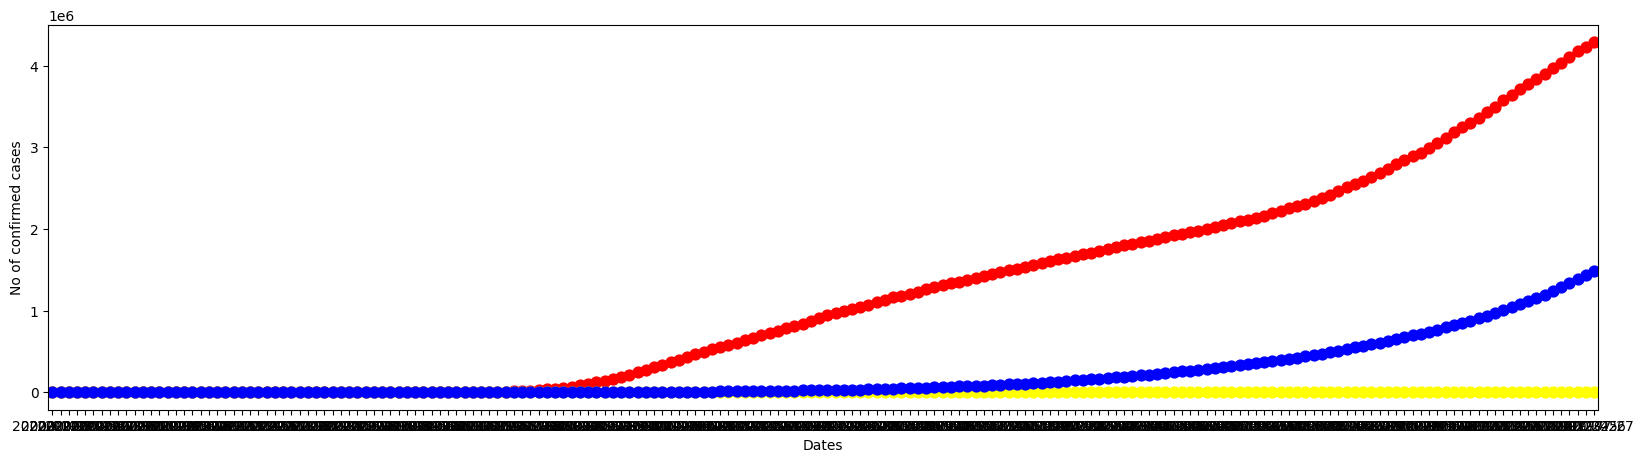

In [263]:
plt.figure(figsize = (20,5))
sns.pointplot(data = US, x = 'Date', y = 'Confirmed', color = 'Red')
sns.pointplot(data = china, x = 'Date', y = 'Confirmed', color = 'Yellow')
sns.pointplot(data = India, x = 'Date', y = 'Confirmed', color = 'Blue')
plt.ylabel('No of confirmed cases')
plt.xlabel('Dates')
plt.show()

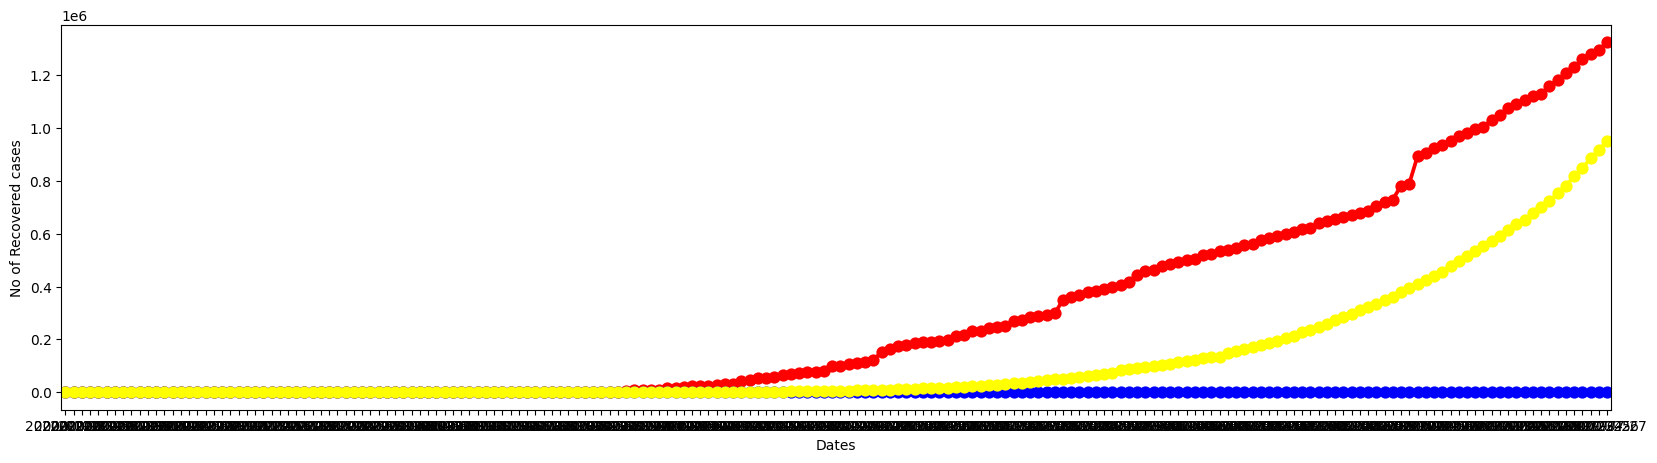

In [264]:
plt.figure(figsize = (20,5))
sns.pointplot(data = US, x = 'Date', y = 'Recovered', color = 'Red')
sns.pointplot(data = china, x = 'Date', y = 'Recovered', color = 'Blue')
sns.pointplot(data = India, x = 'Date', y = 'Recovered', color = 'Yellow')
plt.ylabel('No of Recovered cases')
plt.xlabel('Dates')
plt.show()

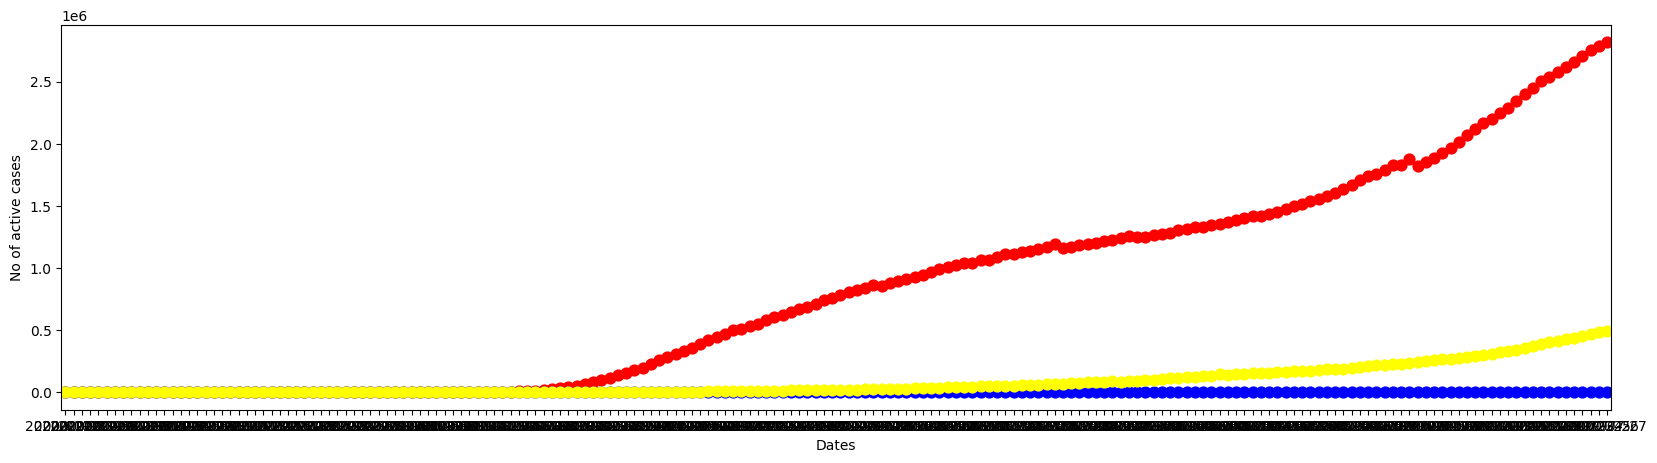

In [265]:
plt.figure(figsize = (20, 5))
sns.pointplot(data = US, x = 'Date', y = 'Active', color = 'red')
sns.pointplot(data = china, x = 'Date', y = 'Active', color = 'Blue')
sns.pointplot(data = India, x = 'Date', y = 'Active', color = 'Yellow')
plt.ylabel('No of active cases')
plt.xlabel('Dates')
plt.show()

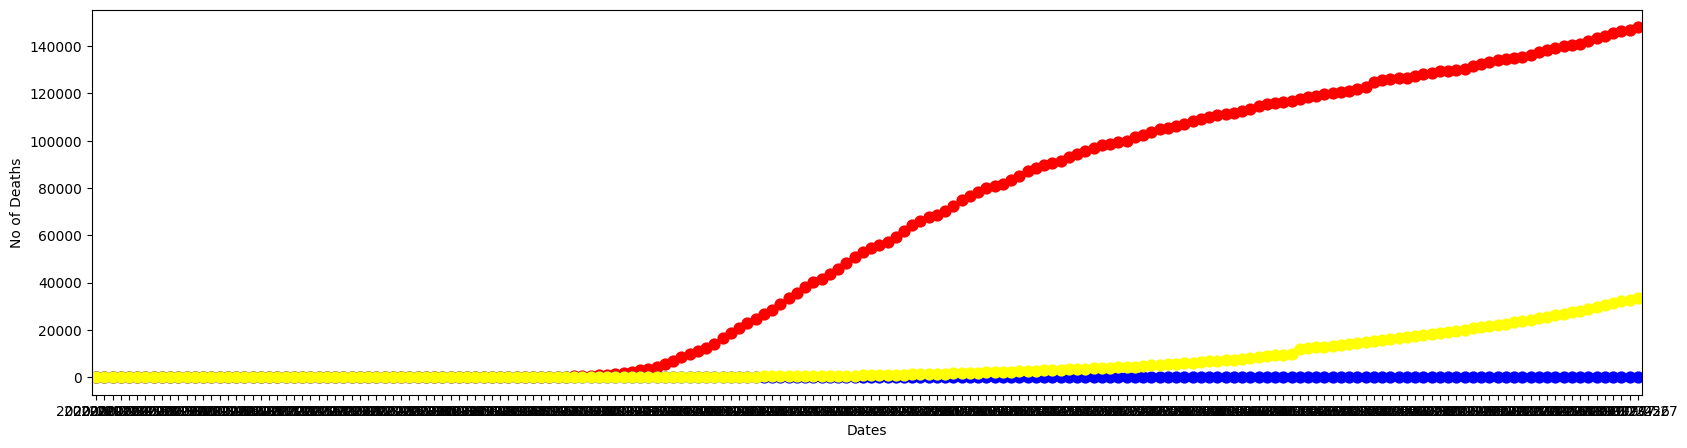

In [266]:
plt.figure(figsize = (20, 5))
sns.pointplot(data = US, x = 'Date', y = 'Deaths', color = 'Red')
sns.pointplot(data = china, x = 'Date', y = 'Deaths', color = 'Blue')
sns.pointplot(data = India, x = 'Date', y = 'Deaths', color = 'Yellow')
plt.ylabel('No of Deaths')
plt.xlabel('Dates')
plt.show()

####**MODEL BUILDING**

In [267]:
!pip install prophet

In [268]:
confirmed_cases = df.groupby(['Date']).sum()['Confirmed'].reset_index()

In [269]:
confirmed_cases.columns=['ds', 'y']
confirmed_cases

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [270]:
from prophet import Prophet

In [271]:
model = Prophet()

In [272]:
model.fit(confirmed_cases)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [273]:
future = model.make_future_dataframe(periods = 7)
forecasted = model.predict(future)
forecasted

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613288e+03,-1.233120e+05,8.307246e+04,-9.613288e+03,-9.613288e+03,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-2.067685e+04
1,2020-01-23,-6.933409e+03,-1.116562e+05,9.910102e+04,-6.933409e+03,-6.933409e+03,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8.050953e+03
2,2020-01-24,-4.253530e+03,-9.630477e+04,1.073746e+05,-4.253530e+03,-4.253530e+03,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5.827449e+03
3,2020-01-25,-1.573651e+03,-9.486794e+04,1.202601e+05,-1.573651e+03,-1.573651e+03,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106228e+03,-1.020381e+05,1.082053e+05,1.106228e+03,1.106228e+03,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674503e+07,1.663962e+07,1.685180e+07,1.673877e+07,1.675037e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685179e+07,1.706377e+07,1.693583e+07,1.696112e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.705089e+07,1.727797e+07,1.712943e+07,1.717276e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.725614e+07,1.747985e+07,1.732384e+07,1.738440e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07


In [274]:
'''
ds:
This column contains the dates for which the predictions have been made. It stands for "date stamp."

yhat:
This is the predicted value (forecast) for the given date in the ds column. It represents the model's best estimate for that point in time.

yhat_upper:
This column represents the upper bound of the predicted value, which indicates the higher end of the confidence interval.
It suggests that the actual value is unlikely to exceed this amount, giving you an idea of the prediction's uncertainty.

yhat_lower:
This column represents the lower bound of the predicted value, indicating the lower end of the confidence interval. It suggests that the actual value is unlikely to be lower than this amount.
'''

'\nds:\nThis column contains the dates for which the predictions have been made. It stands for "date stamp."\n\nyhat:\nThis is the predicted value (forecast) for the given date in the ds column. It represents the model\'s best estimate for that point in time.\n\nyhat_upper:\nThis column represents the upper bound of the predicted value, which indicates the higher end of the confidence interval.\nIt suggests that the actual value is unlikely to exceed this amount, giving you an idea of the prediction\'s uncertainty.\n\nyhat_lower:\nThis column represents the lower bound of the predicted value, indicating the lower end of the confidence interval. It suggests that the actual value is unlikely to be lower than this amount.\n'

In [275]:
forecasted[['yhat_lower', 'yhat', 'yhat_upper']]


,yhat_lower,yhat,yhat_upper
0,-1.233120e+05,-2.067685e+04,8.307246e+04
1,-1.116562e+05,-8.050953e+03,9.910102e+04
2,-9.630477e+04,5.827449e+03,1.073746e+05
3,-9.486794e+04,1.217668e+04,1.202601e+05
4,-1.020381e+05,8.405020e+03,1.082053e+05
...,...,...,...
190,1.663962e+07,1.674392e+07,1.685180e+07
191,1.685179e+07,1.695911e+07,1.706377e+07
192,1.705089e+07,1.716677e+07,1.727797e+07
193,1.725614e+07,1.736430e+07,1.747985e+07


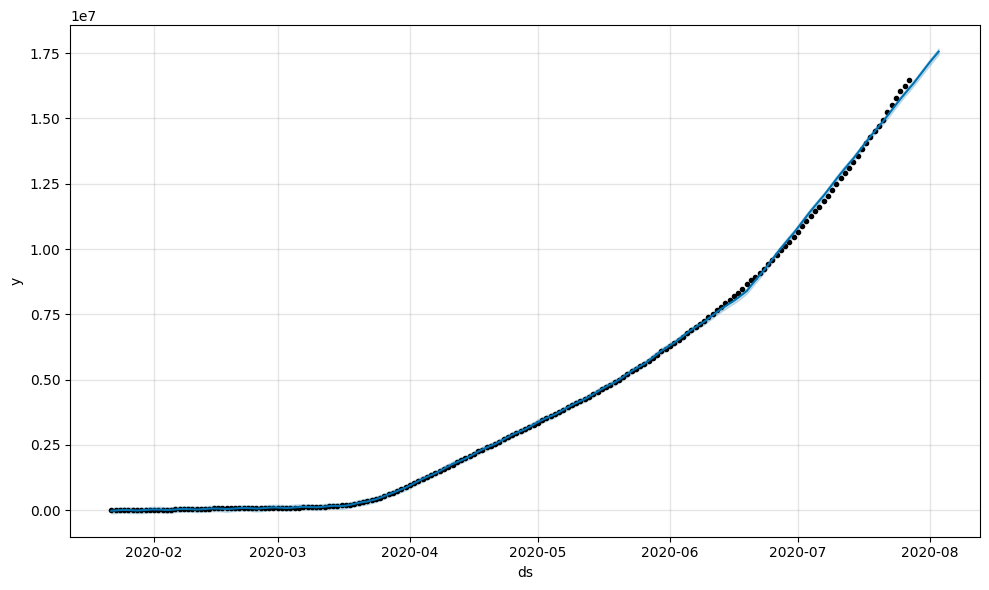

In [276]:
model.plot(forecasted)
plt.show()

In [278]:
df = df.dropna()

In [280]:
recovered_cases.columns = ['ds','y']
#recovered_cases
model_recovered = Prophet()
model_recovered.fit(recovered_cases)
future = model_recovered.make_future_dataframe(periods = 7)
forecasted = model_recovered.predict(future)
forecasted

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-1.360144e+04,-9.800968e+04,6.522542e+04,-1.360144e+04,-1.360144e+04,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,0.0,0.0,0.0,-1.844208e+04
1,2020-01-23,-1.243662e+04,-9.013651e+04,6.475223e+04,-1.243662e+04,-1.243662e+04,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,-1.118182e+04
2,2020-01-24,-1.127180e+04,-8.398749e+04,7.755765e+04,-1.127180e+04,-1.127180e+04,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,-5.175647e+03
3,2020-01-25,-1.010697e+04,-7.593995e+04,7.820044e+04,-1.010697e+04,-1.010697e+04,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,-4.075311e+02
4,2020-01-26,-8.942151e+03,-8.650495e+04,7.000778e+04,-8.942151e+03,-8.942151e+03,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,-9.825630e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,9.594538e+06,9.514648e+06,9.682449e+06,9.590493e+06,9.598798e+06,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,9.595793e+06
191,2020-07-31,9.731096e+06,9.654245e+06,9.821176e+06,9.723303e+06,9.739681e+06,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,9.737193e+06
192,2020-08-01,9.867654e+06,9.801217e+06,9.958536e+06,9.854103e+06,9.881434e+06,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,9.877354e+06
193,2020-08-02,1.000421e+07,9.921213e+06,1.008581e+07,9.985210e+06,1.002362e+07,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,1.000333e+07


In [281]:
active_cases.columns = ['ds', 'y']
model_active = Prophet()
model_active.fit(active_cases)
future = model_active.make_future_dataframe(periods = 7)
forecasted = model_active.predict(future)
forecasted

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-5.051891e+02,-5.336148e+04,3.832144e+04,-5.051891e+02,-5.051891e+02,-5734.815309,-5734.815309,-5734.815309,-5734.815309,-5734.815309,-5734.815309,0.0,0.0,0.0,-6.240004e+03
1,2020-01-23,1.357197e+03,-4.551825e+04,4.403807e+04,1.357197e+03,1.357197e+03,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,0.0,0.0,0.0,-1.186218e+03
2,2020-01-24,3.219584e+03,-3.987982e+04,5.317303e+04,3.219584e+03,3.219584e+03,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,0.0,0.0,0.0,6.450369e+03
3,2020-01-25,5.081970e+03,-3.796877e+04,5.259902e+04,5.081970e+03,5.081970e+03,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,0.0,0.0,0.0,8.209977e+03
4,2020-01-26,6.944356e+03,-3.173359e+04,5.942507e+04,6.944356e+03,6.944356e+03,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,0.0,0.0,0.0,1.509627e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,6.483822e+06,6.435504e+06,6.525724e+06,6.481437e+06,6.486492e+06,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,0.0,0.0,0.0,6.481279e+06
191,2020-07-31,6.546090e+06,6.502972e+06,6.597066e+06,6.540679e+06,6.551436e+06,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,0.0,0.0,0.0,6.549320e+06
192,2020-08-01,6.608357e+06,6.561757e+06,6.659509e+06,6.599551e+06,6.617821e+06,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,0.0,0.0,0.0,6.611485e+06
193,2020-08-02,6.670624e+06,6.628489e+06,6.732613e+06,6.656973e+06,6.684107e+06,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,0.0,0.0,0.0,6.678776e+06


In [282]:
death_cases.columns= ['ds', 'y']
model_death = Prophet()
model_death.fit(death_cases)
future = model_death.make_future_dataframe(periods = 7)
forecasted = model_death.predict(future)
forecasted

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-522.113185,-2597.652928,1142.297540,-522.113185,-522.113185,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,0.0,0.0,0.0,-713.300939
1,2020-01-23,-432.419342,-1913.594406,1979.260301,-432.419342,-432.419342,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,-43.747277
2,2020-01-24,-342.725499,-1414.515061,2595.437365,-342.725499,-342.725499,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,531.538580
3,2020-01-25,-253.031656,-1467.809458,2277.461530,-253.031656,-253.031656,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,473.857809
4,2020-01-26,-163.337813,-2365.914151,1772.269348,-163.337813,-163.337813,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,-328.938272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,663102.734264,661482.297448,665506.865225,662765.432931,663423.020487,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,663491.406328
191,2020-07-31,668132.143204,666949.236187,671229.853813,667444.183515,668777.532696,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,669006.407283
192,2020-08-01,673161.552144,671467.559247,676273.561014,672059.319333,674149.062668,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,673888.441609
193,2020-08-02,678190.961084,675479.288042,680637.865674,676635.937903,679598.723668,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,678025.360624


In [283]:
import plotly

In [284]:
import plotly.express as px

In [285]:
world = df.groupby(['Country'])[['Confirmed', 'Active', 'Deaths', 'Recovered']].sum().reset_index()
world

,Country,Confirmed,Active,Deaths,Recovered
0,Australia,960247,236932,11387,711928
1,Canada,9356551,8656985,699566,0
2,China,14132002,1992723,672413,11466866
3,Denmark,23897,2473,0,21424
4,France,534717,175229,6876,352612
5,Greenland,1507,135,0,1372
6,Netherlands,23007,4054,1986,16967
7,United Kingdom,156490,26130,8258,122102


In [288]:
figure = px.choropleth(world, locations = 'Country', locationmode = 'country names', color = 'Active',hover_name = 'Country', range_color = [1,100000], color_continuous_scale = 'reds', title = 'World map for the Active cases')

In [289]:
figure.show()

####**Conclusion**

Conclusion

In this project, we analyzed COVID-19 data to understand how the virus spread across different countries and how recovery patterns changed over time. By using data visualization, we were able to clearly see which regions were more affected and how active cases were distributed around the world.

The trends showed that the number of cases increased rapidly during certain periods, but recovery rates also improved over time in many regions. Using prediction models, we were able to estimate the number of future cases, which helps in understanding how the situation might change in the short term.

Overall, this project helped in gaining a better understanding of the impact of COVID-19 and showed how data analysis and visualization can be useful in studying real-world problems and making informed predictions.